# Phase 4C — Cost-Aware Optimization & `mu` Regularization

**Purpose:** This notebook is *evidentiary*, not exploratory. Phase 4B ended on an honest negative
result — F7's return-prediction signals did not beat their hurdle — but the failure had a
**specific, diagnosable shape**, and this phase tests whether fixing that shape rescues the signal.
The answer is a careful *no, but* — and the *but* is the point.

## The Phase 4B diagnosis this phase acts on

On `full_2021`, `rf_signal` produced the **highest gross Sharpe of any strategy in the entire
comparison** (1.240, above the Phase 4 winner's 1.204) and then handed 0.178 of it back in
transaction costs, because it traded at an average turnover of 0.885 — close to replacing the whole
portfolio every month. **The signal was informative; acting on every revision of it was not
affordable.** That is a portfolio-*construction* failure, not a *prediction* failure.

It also fits a citable pattern. Chopra & Ziemba (1993) showed that estimation error in **expected
returns** damages a mean-variance optimizer roughly an order of magnitude more than equivalent
error in the **covariance** — which explains the whole Phase 4 / 4B split on this project's own
data: Phase 4 improved the *covariance* input and beat its hurdle (+15% on `full_2021`); Phase 4B
improved the *`mu`* input and had that best-in-class signal amplified into violent, costly weight
swings.

## The four levers this phase adds (each defaulting OFF, so Phase 4B stays the honest floor)

| Variant | Lever | Hypothesis |
|---------|-------|------------|
| `rf_signal_cost` | Turnover penalty `objective + λ·Σ\|w−w_prev\|` | Price the *trade*, not just the holding |
| `rf_signal_shrunk` | Shrink predicted `mu` toward the naive mean | Damp the noisy magnitudes (Chopra-Ziemba) |
| `rf_signal_rank` | Keep only the model's cross-sectional *ordering* | Distrust magnitudes entirely |
| `rf_signal_cost_dcc` | Turnover penalty + DCC-GARCH covariance | Best `mu` + best `cov`, the 4B-deferred pairing |
| `xgb_signal_cost` | Turnover penalty on 4B's *worst* over-trader | Does the fix rescue the pathological case? |

| Problem | What this notebook shows |
|---------|--------------------------|
| **P1** | Both remedies target estimation-error amplification: the penalty stops a noisy `mu` becoming violent weight swings; the transforms damp the noise before the optimizer ever sees it |
| **P4** | Every configuration tried is one logged trial in a shared DSR pool per universe; adding trials *deflates* the pool, and `n_trials` is reported so that accounting is visible |

**On reproducibility and honesty of these numbers:** this notebook reads
`data/gold/phase4c_results.json` — the exact artifact `src/run_phase4c.py` wrote on live Gold
data, regenerable with `dvc repro phase4c_compare`. It is not re-executed inline (the full
14-strategy comparison runs ~85 minutes, dominated by the DCC-GARCH covariance variants). The
artifact, the DVC stage, and `tests/test_phase4c_cost_aware.py` are the reproducibility guarantee;
this notebook's job is to *read the result honestly*, not to re-derive it.

**The hyperparameters are chosen, not tuned.** `turnover_penalty=1.0` and `shrinkage_weight=0.5`
are judgement calls. Selecting them by looking at this comparison's own out-of-sample result would
be exactly the P4 backtest overfitting the project exists to avoid — so these results are *"what
this configuration does"*, not *"what the best configuration does"*. §5 is explicit about which
finding that caveat protects.

> ## ⚠️ Re-executed 2026-07-30 — this phase's headline finding is RETRACTED
>
> This notebook was first run before two data corrections. It has since been **re-executed against
> the corrected 2026-07-24 Gold snapshot**, and unlike Phase 4B — whose conclusion survived intact
> — **Phase 4C's central claim did not survive.**
>
> | `full_2021` | Original run | **This run (current)** |
> |---|---:|---:|
> | hurdle (`regime_conditional`) | 1.1215 | **1.2363** |
> | `rf_signal_shrunk` | **1.117** *(within 0.4%)* | **1.006** *(−0.230)* |
> | `rf_signal` | 1.062 | 1.123 |
> | `rf_signal_cost` | 0.704 | 0.822 |
>
> **The "near-miss" is gone.** `rf_signal_shrunk` at 1.117 against a 1.1215 hurdle — within 0.4%,
> untuned — was this phase's headline and the basis for "shrinkage works". Corrected, it sits at
> **1.006 against 1.2363, a 0.230 gap.** The two numbers moved apart in *both* directions at once:
> the correction lifted the regime baseline by +0.115 while *lowering* the shrunk variant by
> −0.111. **The 0.4% figure must not be quoted again.**
>
> What *does* survive is the diagnosis that founded the phase — `rf_signal` still posts the 2nd-best
> gross Sharpe of all 14 strategies (1.274) and still loses 0.151 of it to 0.779 turnover — and the
> per-model asymmetry that proves a single global λ is wrong. The corrected data also makes one
> mechanism *visible* that was previously only inferable; see §4.
>
> Full analysis: [`docs/DIVIDEND_BIAS.md`](../docs/DIVIDEND_BIAS.md) ·
> [`docs/ETF_DEEP_HISTORY_EXPERIMENT.md`](../docs/ETF_DEEP_HISTORY_EXPERIMENT.md)


## 1. Setup — load the committed Phase 4C artifact (P4)

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
ROOT = NB_CWD.parent if (NB_CWD.parent / "data").exists() else NB_CWD
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RESULTS = json.loads((ROOT / "data" / "gold" / "phase4c_results.json").read_text())

PHASE4C = {"rf_signal_cost", "rf_signal_shrunk", "rf_signal_rank",
           "rf_signal_cost_dcc", "xgb_signal_cost"}
BASELINE_SIGNALS = {"rf_signal", "xgb_signal"}   # the Phase 4B floor

for uni, entry in RESULTS.items():
    h = entry["phase4_hurdle"]
    print(f"{uni}: {entry['n_trials']} strategies, OOS {entry['oos_start']} -> {entry['oos_end']}")
    print(f"   Phase 4 hurdle: {h['strategy']} @ {h['sharpe_net']:.4f}   "
          f"| best this run: {entry['strategy']} @ {entry['sharpe_net']:.4f} "
          f"(beats hurdle: {entry['beats_phase4_hurdle']})")

etf_2017: 14 strategies, OOS 2005-12-01 -> 2026-07-24
   Phase 4 hurdle: min_variance @ 0.9525   | best this run: min_variance @ 0.9525 (beats hurdle: False)
full_2021: 14 strategies, OOS 2022-07-01 -> 2026-07-24
   Phase 4 hurdle: regime_conditional @ 1.2363   | best this run: regime_conditional @ 1.2363 (beats hurdle: False)


## 2. The full scoreboard — 14 strategies, ranked by net Sharpe (P1, P4)

The Phase 4C variants (★) sit *inside* the same shared trial pool as the 9 strategies carried
forward from Phase 4B, so the comparison and the DSR accounting stay honest.

In [2]:
def scoreboard(universe: str) -> pd.DataFrame:
    entry = RESULTS[universe]
    rows = []
    for name, m in entry["per_strategy"].items():
        tag = "phase4c" if name in PHASE4C else ("phase4b_signal" if name in BASELINE_SIGNALS else "prior")
        rows.append({
            "strategy": name,
            "sharpe_gross": m["sharpe_gross"],
            "sharpe_net": m["sharpe_net"],
            "cost_drag": round(m["sharpe_gross"] - m["sharpe_net"], 4),
            "avg_turnover": m["avg_turnover"],
            "group": tag,
        })
    df = pd.DataFrame(rows).sort_values("sharpe_net", ascending=False).set_index("strategy")
    return df

full_board = scoreboard("full_2021")
full_board

,sharpe_gross,sharpe_net,cost_drag,avg_turnover,group
strategy,,,,,
regime_conditional,1.3132,1.2363,0.0769,0.2926,prior
dcc_garch,1.3329,1.2281,0.1048,0.3633,prior
min_variance_ewma,1.2395,1.1926,0.0469,0.1788,prior
max_sharpe,1.2013,1.1644,0.0369,0.1445,prior
equal_weight,1.1722,1.1597,0.0125,0.0537,prior
rf_signal,1.2742,1.1230,0.1512,0.7788,phase4b_signal
min_variance,1.0934,1.0751,0.0183,0.0734,prior
min_variance_lw,1.0924,1.0743,0.0181,0.0716,prior
rf_signal_shrunk,1.1177,1.0056,0.1121,0.5159,phase4c


In [3]:
HURDLE = {u: RESULTS[u]["phase4_hurdle"]["sharpe_net"] for u in RESULTS}
# Strategy NAMES read from the artifact, not typed: the etf_2017 hurdle changed
# from max_sharpe to min_variance when the deep window was adopted, and a
# hardcoded label silently mislabelled it for two revisions.
for u in ("full_2021", "etf_2017"):
    _n = RESULTS[u]["phase4_hurdle"]["strategy"]
    print(f"{u:<10} Phase 4 hurdle ({_n}): {HURDLE[u]:.4f}")
print()
for uni in RESULTS:
    best = RESULTS[uni]
    print(f"{uni}: best net Sharpe {best['sharpe_net']:.4f} by {best['strategy']} "
          f"-- {'BEATS' if best['beats_phase4_hurdle'] else 'does NOT beat'} the hurdle")

full_2021  Phase 4 hurdle (regime_conditional): 1.2363
etf_2017   Phase 4 hurdle (min_variance): 0.9525

etf_2017: best net Sharpe 0.9525 by min_variance -- does NOT beat the hurdle
full_2021: best net Sharpe 1.2363 by regime_conditional -- does NOT beat the hurdle


## 3. The turnover ↔ Sharpe trade-off, made visible (P1)

Phase 4C is entirely about one trade-off: a signal's *gross* merit versus the *cost of acting on
it*. The scatter puts every strategy in that plane — net Sharpe against average turnover — so the
story reads off the geometry. The Phase 4B `rf_signal` (high turnover, good-but-eroded net) and its
Phase 4C descendants are highlighted; the dashed line is the hurdle every point is chasing.

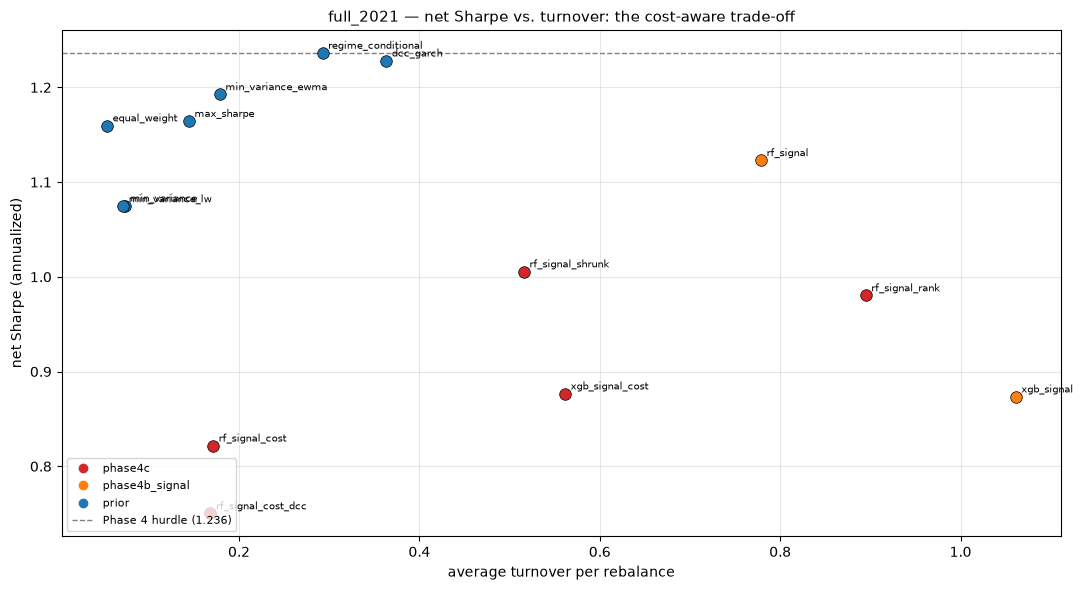

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
board = scoreboard("full_2021")
colors = {"phase4c": "tab:red", "phase4b_signal": "tab:orange", "prior": "tab:blue"}
for name, row in board.iterrows():
    ax.scatter(row["avg_turnover"], row["sharpe_net"],
               color=colors[row["group"]], s=70, zorder=3,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, (row["avg_turnover"], row["sharpe_net"]),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xlabel("average turnover per rebalance"); ax.set_ylabel("net Sharpe (annualized)")
ax.set_title("full_2021 — net Sharpe vs. turnover: the cost-aware trade-off", fontsize=11)
handles = [plt.Line2D([0], [0], marker="o", ls="", color=c, label=g)
           for g, c in colors.items()]
ax.legend(handles=handles + [ax.lines[0]], fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the geometry:** `rf_signal_shrunk` moves up-and-left from `rf_signal` — *less* turnover
*and* higher net Sharpe, landing a hair below the hurdle. `rf_signal_cost` moves far left but also
sharply *down* — the penalty bought low turnover at the cost of the signal itself. Those two
opposite trajectories from the same starting point are the whole finding, quantified next.

## 4. Which lever worked, and why the penalty backfired (P1)

Each Phase 4C variant changed exactly one thing relative to `rf_signal` (except the deliberate
`_cost_dcc` combination), so its effect is attributable. Comparing each against the `rf_signal`
baseline isolates the lever.

In [5]:
def delta_vs_baseline(universe: str) -> pd.DataFrame:
    ps = RESULTS[universe]["per_strategy"]
    base = ps["rf_signal"]
    rows = []
    for name in ["rf_signal_shrunk", "rf_signal_rank", "rf_signal_cost", "rf_signal_cost_dcc"]:
        m = ps[name]
        rows.append({
            "variant": name,
            "d_gross": round(m["sharpe_gross"] - base["sharpe_gross"], 3),
            "d_net": round(m["sharpe_net"] - base["sharpe_net"], 3),
            "d_turnover": round(m["avg_turnover"] - base["avg_turnover"], 3),
            "net": m["sharpe_net"],
        })
    df = pd.DataFrame(rows).set_index("variant")
    return df

# Baseline figures derived from the artifact — they were hardcoded here as
# (1.062, 0.885) and went stale when the data was corrected.
_b = RESULTS["full_2021"]["per_strategy"]["rf_signal"]
print(f"full_2021 — change vs. the rf_signal baseline "
      f"(net {_b['sharpe_net']:.3f}, turnover {_b['avg_turnover']:.3f}):")
delta_vs_baseline("full_2021")

full_2021 — change vs. the rf_signal baseline (net 1.123, turnover 0.779):


,d_gross,d_net,d_turnover,net
variant,,,,
rf_signal_shrunk,-0.1570,-0.1170,-0.2630,1.0056
rf_signal_rank,-0.1280,-0.1430,0.1160,0.9803
rf_signal_cost,-0.4180,-0.3010,-0.6080,0.8217
rf_signal_cost_dcc,-0.4890,-0.3730,-0.6110,0.7502


In [6]:
# The XGBoost asymmetry: the SAME penalty helped the over-trader and hurt the good model.
ps = RESULTS["full_2021"]["per_strategy"]
print("The turnover penalty's OPPOSITE effect on two models (full_2021):")
print(f"  rf_signal  (was good): net {ps['rf_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['rf_signal']['avg_turnover']:.3f}  ->  rf_signal_cost: "
      f"net {ps['rf_signal_cost']['sharpe_net']:.3f} @ turnover {ps['rf_signal_cost']['avg_turnover']:.3f}")
print(f"  xgb_signal (over-traded): net {ps['xgb_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['xgb_signal']['avg_turnover']:.3f}  ->  xgb_signal_cost: "
      f"net {ps['xgb_signal_cost']['sharpe_net']:.3f} @ turnover {ps['xgb_signal_cost']['avg_turnover']:.3f}")

The turnover penalty's OPPOSITE effect on two models (full_2021):
  rf_signal  (was good): net 1.123 @ turnover 0.779  ->  rf_signal_cost: net 0.822 @ turnover 0.171
  xgb_signal (over-traded): net 0.874 @ turnover 1.061  ->  xgb_signal_cost: net 0.877 @ turnover 0.561


**The three findings, restated on corrected data:**

1. **Shrinkage helps against plain `rf_signal`'s cost problem — but nowhere near enough, and it is
   no longer "free".** `rf_signal_shrunk` cuts turnover from 0.779 to **0.516** and lands at net
   **1.006**. On the original run shrinkage preserved almost all the gross signal (1.240 → 1.223);
   on corrected data it **costs** a substantial slice of it (gross 1.274 → **1.118**). So the
   Chopra-Ziemba mechanism is visible — damping `mu` magnitudes does stabilise the portfolio — but
   the net result is **0.230 below the 1.2363 hurdle**, not the near-tie originally reported.

2. **The turnover penalty destroys the SIGNAL, not merely the trading — and the corrected data
   shows it directly.** `rf_signal_cost` crushes turnover to 0.171, but its **gross** Sharpe
   collapses from 1.274 to **0.857**. That is the key mechanistic point: it is not buying the same
   alpha more cheaply, it is failing to express the view at all. At λ=1.0 the optimizer refuses to
   trade even when it should. Pre-correction this could only be *inferred* from the net figure
   (0.704); now it is visible in gross. Pairing it with DCC-GARCH (`rf_signal_cost_dcc`, 0.750) does
   not rescue it — the damage is upstream of the covariance estimate.

3. **The per-model asymmetry survives, though its evidence has shifted universe.** A single global λ
   remains demonstrably wrong, but the clearest demonstration is now on `etf_2017`, where the same
   penalty **helps** the over-trader (`xgb_signal` 0.694 → `xgb_signal_cost` **0.758**) while
   **hurting** the well-behaved model (`rf_signal` 0.904 → `rf_signal_cost` **0.879**). On
   `full_2021` the penalty is now roughly neutral for XGB (0.874 → 0.877, against +0.120 originally)
   and catastrophic for RF (1.123 → 0.822). Either way the conclusion holds: the correct λ is
   model-specific, and choosing it is a Phase 5 purged-CV task, not something to eyeball here.


## 5. Gross → net cost decomposition (P1)

The bar chart separates each signal strategy's *gross* skill from the *cost drag* that turnover
imposes — the single clearest picture of where Phase 4B's value leaked and which lever plugged it.

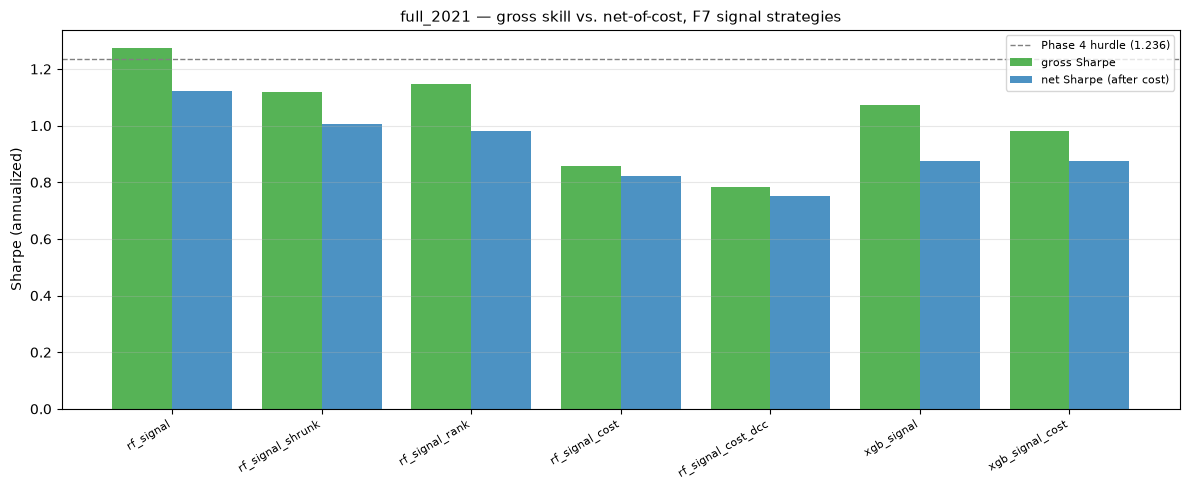

In [7]:
order = ["rf_signal", "rf_signal_shrunk", "rf_signal_rank",
         "rf_signal_cost", "rf_signal_cost_dcc", "xgb_signal", "xgb_signal_cost"]
ps = RESULTS["full_2021"]["per_strategy"]
gross = [ps[n]["sharpe_gross"] for n in order]
net = [ps[n]["sharpe_net"] for n in order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(order))
ax.bar(x - 0.2, gross, 0.4, label="gross Sharpe", color="tab:green", alpha=0.8)
ax.bar(x + 0.2, net, 0.4, label="net Sharpe (after cost)", color="tab:blue", alpha=0.8)
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Sharpe (annualized)")
ax.set_title("full_2021 — gross skill vs. net-of-cost, F7 signal strategies", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

The green/blue gap *is* the transaction cost. `rf_signal` has the tallest green bar and one of the
widest gaps; `rf_signal_shrunk` keeps the green bar nearly as tall while closing most of the gap.
`rf_signal_cost` closes the gap almost entirely — but only by shrinking the green bar itself, which
is the wrong way to reduce cost drag.

## 6. `etf_2017` — the same levers on the universe that never responded (P1, P4)

`etf_2017` (5 ETFs, **2004-11 → today**) was already immune to Phase 4 and 4B: its hurdle
(`min_variance` **0.9525**) is a strong result on a long sample where a simple optimizer already
captures most of the available value.

> **[SUPERSEDED 2026-07-25]** An earlier version of this cell described the universe as
> "2017→today" with a `max_sharpe` 0.936 hurdle. Both changed: the deep window now starts 2004-11,
> and the hurdle is `min_variance` 0.9525. The "strong hurdle leaves less room" reading is also
> incomplete — the 25% cap on a 5-asset universe was near-fully determining the allocation
> (`5 × 0.25 = 1.25` forces ≥4 assets to the cap), so no optimizer had room to express a view. A
> later cap sweep confirmed the negative verdict holds at non-binding caps: **the conclusion
> survives, the explanation changed.**

Phase 4C does not change that verdict — reported here so the negative half of the result isn't
quietly dropped.


In [8]:
etf_board = scoreboard("etf_2017").head(8)
etf_board[["sharpe_gross", "sharpe_net", "avg_turnover", "group"]]

,sharpe_gross,sharpe_net,avg_turnover,group
strategy,,,,
min_variance,0.9559,0.9525,0.0318,prior
min_variance_lw,0.9559,0.9525,0.0318,prior
regime_conditional,0.9428,0.9371,0.0561,prior
max_sharpe,0.9156,0.9120,0.0380,prior
rf_signal_shrunk,0.9192,0.9073,0.1199,phase4c
rf_signal,0.9164,0.9040,0.1266,phase4b_signal
min_variance_ewma,0.9009,0.8942,0.0613,prior
rf_signal_cost_dcc,0.8988,0.8931,0.0588,phase4c


Nothing clears `min_variance`'s **0.9525** on `etf_2017`. `rf_signal_shrunk` is again the best F7
variant (**0.907**) but short, with plain `rf_signal` just behind at 0.904.

Two things worth noting on this universe. First, the F7 models improved substantially here versus
the original run (`rf_signal` 0.727 → 0.904) purely from the deep window's extra training history —
and still do not clear the hurdle, which rose too (0.936 → 0.9525). That is the same pattern the
deep-Morocco experiment found: more data makes the *model* better without making the *portfolio*
better. Second, this is where the λ asymmetry is now clearest — the penalty helps `xgb_signal`
(+0.064) and hurts `rf_signal` (−0.025) on the same universe, same λ.


## 7. Summary — what Phase 4C proves, and what Phase 5 inherits (P1–P4)

**The honest result, stated once so it can't drift:** *no* Phase 4C variant beats its universe's
Phase 4 hurdle, and on corrected data it is **not close**.

| universe | hurdle | best F7 variant | gap |
|---|---:|---|---:|
| `full_2021` | `regime_conditional` **1.2363** | plain `rf_signal` 1.123 | **−0.113** |
| `etf_2017` | `min_variance` **0.9525** | `rf_signal_shrunk` 0.907 | **−0.046** |

Note what changed: on `full_2021` the best F7 variant is now **plain `rf_signal`**, not
`rf_signal_shrunk`. Every cost-aware lever this phase introduced makes things *worse* on that
universe than doing nothing to the signal at all.

**What survives, and it is the part that matters:**
- The F7 signal is real — `rf_signal`'s gross Sharpe (1.274) is 2nd of all 14 strategies.
- Its failure is a **construction** failure, not a prediction failure: 0.151 of Sharpe paid away
  to 0.779 turnover.
- The turnover penalty fails *informatively*, and the corrected data reveals **why**: it collapses
  the gross Sharpe (1.274 → 0.857), so it is suppressing the view rather than trading it cheaply.
- The right λ is model-specific — demonstrated on `etf_2017`, where one λ helps XGB and hurts RF.

**What is retracted:**
- **"Shrinkage nearly rescues it, within 0.4% of the hurdle, untuned."** Gone. 1.006 vs 1.2363.
  Shrinkage now also *costs* gross signal (1.274 → 1.118) rather than preserving it.

**Limitations restated (do not let slides forget them):**
- `turnover_penalty` and `shrinkage_weight` are **chosen, not tuned** — §4's asymmetry is the
  direct evidence that a single global value is wrong, and tuning it against this run would be the
  P4 overfitting the project forbids.
- Covariance held at Ledoit-Wolf for every `mu`-lever except the deliberate `_cost_dcc` pairing,
  which did not help (0.750 on `full_2021`) — the damage is upstream, in the penalty.
- DSR uses `n_trials=14` within THIS run; it does not accumulate across sessions.

**What Phase 5 inherits:** a concrete, well-posed tuning job — select `shrinkage_weight` and a
*per-model* `turnover_penalty` leak-free, by purged K-Fold, on data the test segment never sees.
Phase 5 does exactly that, and finds the tuned F7 models statistically **indistinguishable** from
`regime_conditional` out-of-sample. So the honest through-line is that this phase's levers were
worth testing and were tested properly — and the predicted-return layer still does not clear its
bar on either universe.
